<a href="https://colab.research.google.com/github/YatzyOmg/Particle-Physics/blob/main/Reconstrucci%C3%B3n_de_la_masa_invariante_de_un_par_de_muones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo de masa invariante de una base de datos de colisiones
Empezamos importando las librerias importantes que se utilizan en este analísis de datos tales como son pandas, numpy y matplotlib para las gráficas. Posteriormente se añade a la variable ´´url´´ el link de esta base de datos en formato csv para luego leerlo con pandas, finalmente se imprime información importante para nuestro análisis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = "https://opendata.cern.ch/record/5208/files/Zmumu.csv"
df = pd.read_csv(url)
df.head()

,Run,Event,pt1,eta1,phi1,Q1,dxy1,iso1,pt2,eta2,phi2,Q2,dxy2,iso2
0,165617,74969122,54.7055,-0.4324,2.5742,1,-0.0745,0.4999,34.2464,-0.9885,-0.4987,-1,0.0712,3.4221
1,165617,75138253,24.5872,-2.0522,2.8666,-1,-0.0554,0.0000,28.5389,0.3852,-1.9912,1,0.0515,0.0000
2,165617,75887636,31.7386,-2.2595,-1.3323,-1,0.0879,0.0000,30.2344,-0.4684,1.8833,1,-0.0876,0.0000
3,165617,75779415,39.7394,-0.7123,-0.3123,1,0.0585,0.0000,48.2790,-0.1956,2.9703,-1,-0.0492,0.0000
4,165617,75098104,41.2998,-0.1571,-3.0408,1,-0.0305,1.2280,43.4508,0.5910,-0.0428,-1,0.0442,0.0000


In [2]:
df.shape

(10000, 14)

Es importante convertir las variables numéricas del conjunto de datos a un formato numérico antes de realizar los cálculos. Al leer un archivo CSV, algunas variables pueden ser interpretadas por Pandas como cadenas de texto (str), como el momento transversal (pt), la pseudorapidez (eta) y el ángulo azimutal (phi) de ambos muones. El ciclo for permite aplicar la conversión a cada columna de manera automática. Además, errors="coerce" hace que cualquier valor que no pueda convertirse en número sea reemplazado por NaN, evitando que el programa se detenga por un dato incorrecto.

In [3]:
# Convertir las variables numéricas a tipo float
columnas_numericas = [
    "pt1", "eta1", "phi1", "Q1", "dxy1", "iso1",
    "pt2", "eta2", "phi2", "Q2", "dxy2", "iso2"
]

for columna in columnas_numericas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

Para reconstruir la masa invariante del par de muones, primero se calculan las diferencias entre sus valores de pseudorapidez (eta) y de ángulo azimutal (phi). Estas diferencias permiten describir la separación angular entre los dos muones.

En el caso de delta_phi, se realiza una transformación para mantener su valor dentro del intervalo ([-\pi,\pi]). Esto es necesario porque el ángulo azimutal es periódico y una diferencia directa entre dos ángulos puede producir valores fuera de este intervalo.

Posteriormente, se calcula la masa invariante del sistema de los dos muones.

In [4]:
# Diferencias de eta y phi
delta_eta = df["eta1"] - df["eta2"]
delta_phi = df["phi1"] - df["phi2"]
# Llevar Delta phi al intervalo [-pi, pi]
delta_phi = np.arctan2(np.sin(delta_phi), np.cos(delta_phi))
# Masa invariante del par de muones
df["M_mumu"] = np.sqrt(
    2 * df["pt1"] * df["pt2"] *
    (np.cosh(delta_eta) - np.cos(delta_phi))
)
# Estadísticas de la masa
df["M_mumu"].describe()

,M_mumu
count,10000.000000
mean,87.973980
std,8.840568
min,60.002249
25%,86.940134
50%,90.285408
75%,92.152627
max,119.952704


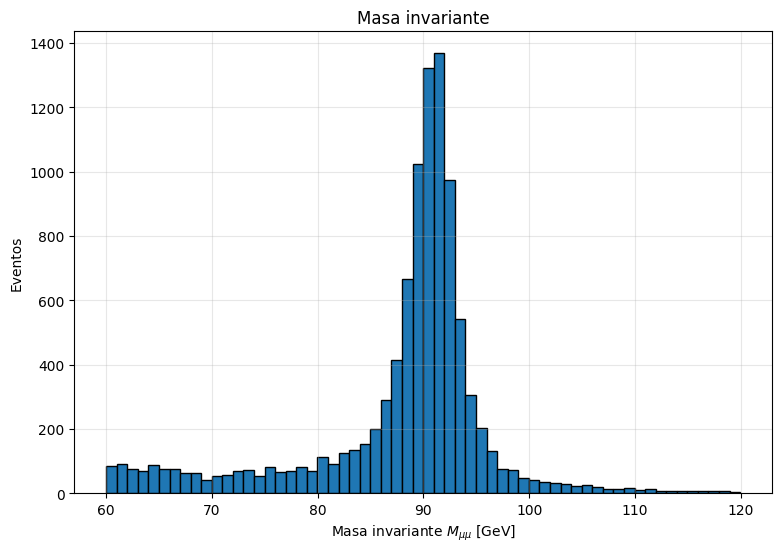

In [5]:
#Histograma de masa
plt.figure(figsize=(9,6))

plt.hist(
    df["M_mumu"],
    bins=60,
    edgecolor="black"
)

plt.xlabel(r"Masa invariante $M_{\mu\mu}$ [GeV]")
plt.ylabel("Eventos")
plt.title("Masa invariante")

plt.grid(alpha=0.3)
plt.show()

La distribución del momento transversal \(p_T\) muestra valores superiores a \(20\) GeV para ambos muones. Esto no significa que los muones producidos en general tengan \(p_T>20\) GeV, sino que es consecuencia directa del corte aplicado previamente a la muestra. Las distribuciones de \(p_{T1}\) y \(p_{T2}\) presentan un comportamiento similar, lo cual es consistente con que ambos muones provienen del mismo proceso de decaimiento del bosón \(Z--->mu^+\mu^-\). Las diferencias entre los valores de \(p_T\) de ambos muones se deben a la cinemática del evento y al momento transversal que pueda tener el bosón \(Z\).

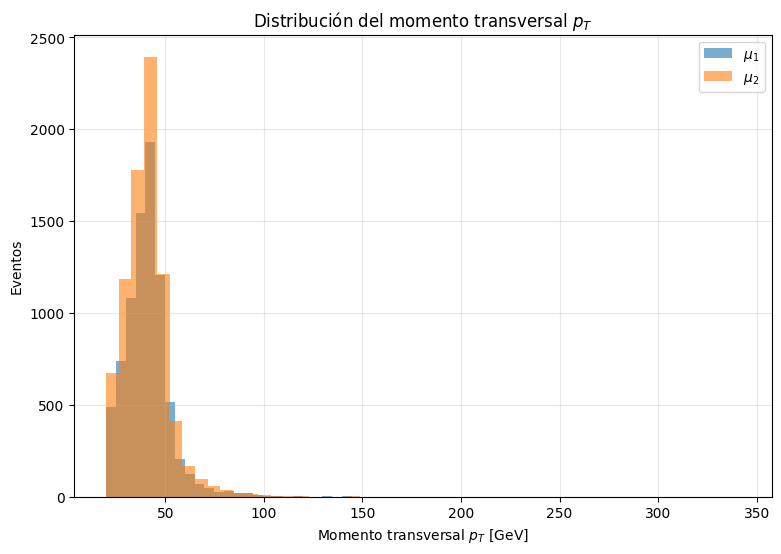

In [6]:
# pT > 20 GeV
# |eta| < 2.1
# 60 < M_mumu < 120 GeV
df_sel = df[
    (df["pt1"] > 20) &
    (df["pt2"] > 20) &
    (abs(df["eta1"]) < 2.1) &
    (abs(df["eta2"]) < 2.1) &
    (df["M_mumu"] > 60) &
    (df["M_mumu"] < 120)
].copy()
#Momento Transversal
plt.figure(figsize=(9,6))

plt.hist(
    df_sel["pt1"],
    bins=50,
    alpha=0.6,
    label=r"$\mu_1$"
)
plt.hist(
    df_sel["pt2"],
    bins=50,
    alpha=0.6,
    label=r"$\mu_2$"
)
plt.xlabel(r"Momento transversal $p_T$ [GeV]")
plt.ylabel("Eventos")
plt.title(r"Distribución del momento transversal $p_T$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Las distribuciones de pseudorrapidez de ambos muones presentan un comportamiento semejante y están restringidas aproximadamente al intervalo

$$ -2.1 < \eta < 2.1, $$

debido al corte utilizado para seleccionar los eventos. Por esta razón, la ausencia de muones fuera de este intervalo tampoco debe interpretarse como una propiedad general de los muones, sino como una consecuencia de la selección.

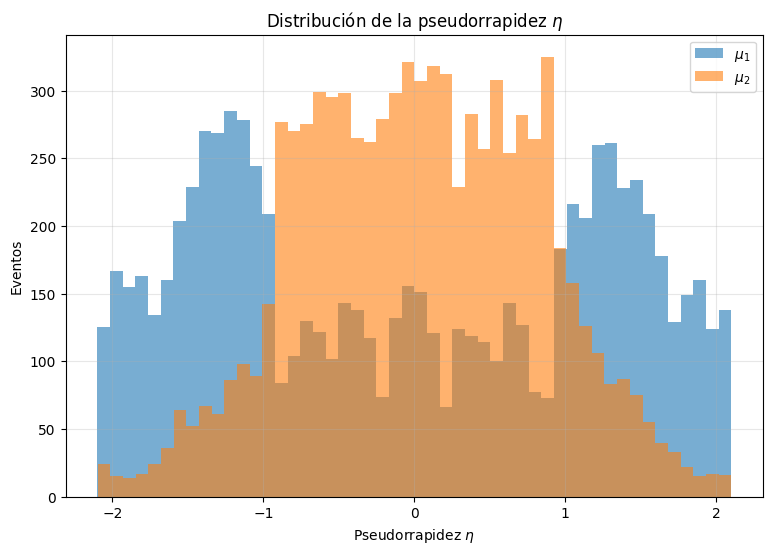

In [7]:
#pseudorapidez
plt.figure(figsize=(9,6))

plt.hist(
    df_sel["eta1"],
    bins=50,
    alpha=0.6,
    label=r"$\mu_1$"
)

plt.hist(
    df_sel["eta2"],
    bins=50,
    alpha=0.6,
    label=r"$\mu_2$"
)

plt.xlabel(r"Pseudorrapidez $\eta$")
plt.ylabel("Eventos")
plt.title(r"Distribución de la pseudorrapidez $\eta$")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Aquí el eje horizontal representa el ángulo azimutal:

$$−π≤ \phi ≤π$$
Lo primero que se puede notar es que ambos muones tienen valores de \(\phi\) distribuidos prácticamente a lo largo de todo el intervalo. No hay un pico único y pronunciado en un determinado ángulo.

Esto significa que, en la muestra, no existe una dirección azimutal preferida para la producción de los muones. Es decir, el proceso no parece favorecer que los muones salgan siempre hacia una dirección particular del plano transversal.

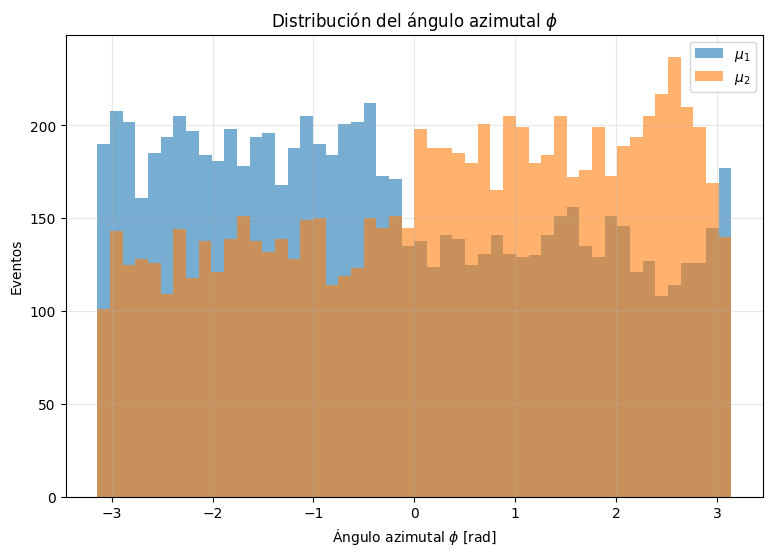

In [8]:
# angulo azimutal phi
plt.figure(figsize=(9,6))

plt.hist(
    df_sel["phi1"],
    bins=50,
    alpha=0.6,
    label=r"$\mu_1$"
)

plt.hist(
    df_sel["phi2"],
    bins=50,
    alpha=0.6,
    label=r"$\mu_2$"
)

plt.xlabel(r"Ángulo azimutal $\phi$ [rad]")
plt.ylabel("Eventos")
plt.title(r"Distribución del ángulo azimutal $\phi$")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

La distribución de carga es una de las características más importantes de esta muestra. Se espera que los eventos correspondientes al proceso

$$ Z\rightarrow\mu^+\mu^- $$

contengan un muón con carga \(+1\) y otro con carga \(-1\). Por lo tanto, las cargas de ambos muones deben ser opuestas.

En consecuencia, si un evento tiene

$$ Q_1=+1, $$

se espera que

$$ Q_2=-1, $$

y viceversa. Esta característica constituye una comprobación física importante de que los dos objetos identificados son compatibles con un par \(\mu^+\mu^-\) producido en el decaimiento de un bosón \(Z\).

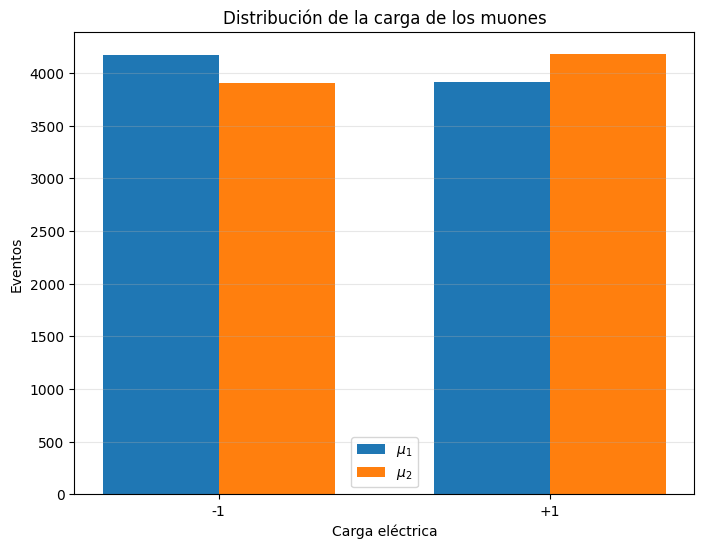

In [9]:
# Carga electrica
plt.figure(figsize=(8,6))

cargas = [-1, 1]

Q1 = df_sel["Q1"].value_counts().reindex(cargas, fill_value=0)
Q2 = df_sel["Q2"].value_counts().reindex(cargas, fill_value=0)

x = np.arange(len(cargas))
ancho = 0.35

plt.bar(
    x - ancho/2,
    Q1.values,
    ancho,
    label=r"$\mu_1$"
)

plt.bar(
    x + ancho/2,
    Q2.values,
    ancho,
    label=r"$\mu_2$"
)

plt.xticks(x, ["-1", "+1"])
plt.xlabel("Carga eléctrica")
plt.ylabel("Eventos")
plt.title("Distribución de la carga de los muones")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

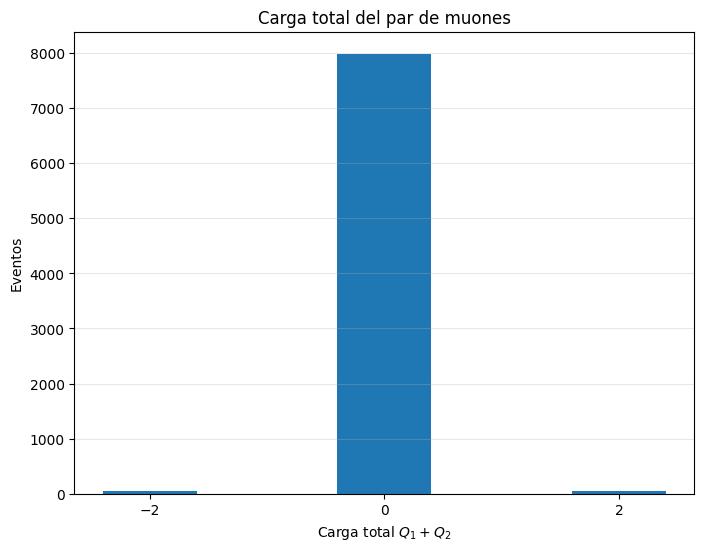

In [19]:
# Carga total del par de muones
df_sel["Q_total"] = df_sel["Q1"] + df_sel["Q2"]

plt.figure(figsize=(8,6))

plt.hist(
    df_sel["Q_total"],
    bins=np.arange(-2.5, 3, 1),
    rwidth=0.8
)

plt.xticks([-2, 0, 2])
plt.xlabel(r"Carga total $Q_1 + Q_2$")
plt.ylabel("Eventos")
plt.title("Carga total del par de muones")
plt.grid(axis="y", alpha=0.3)

plt.show()

El aislamiento permite estudiar qué tan rodeado está cada muón por otras partículas o actividad asociada al evento. Una distribución concentrada en valores pequeños de aislamiento indica que los muones tienden a encontrarse relativamente aislados.Si el muón tiene poco aislamiento, significa que hay relativamente poca actividad alrededor de él.

Si tiene un valor de aislamiento grande, significa que está acompañado por más actividad.

Para \(Z--->mu^+\mu^-\), esperamos encontrar muones relativamente aislados, porque los muones provienen directamente del decaimiento del \(Z\), en lugar de estar necesariamente dentro de un jet.

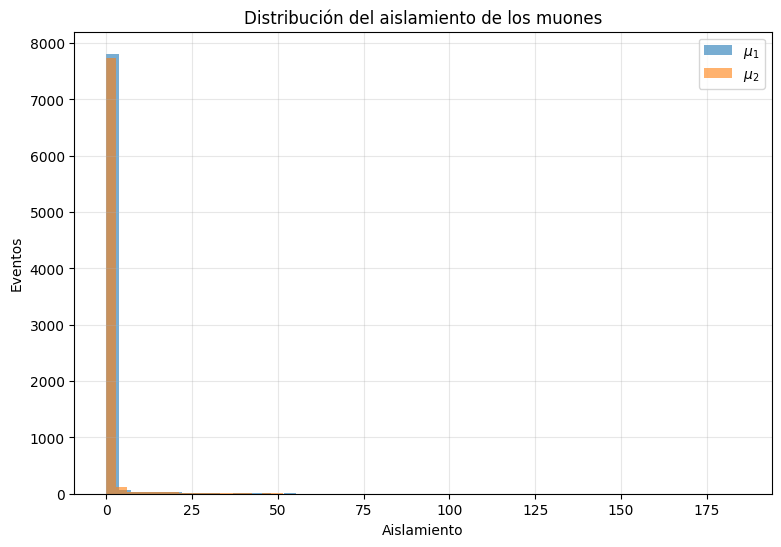

In [10]:
# Aislamiento
plt.figure(figsize=(9,6))

plt.hist(
    df_sel["iso1"],
    bins=50,
    alpha=0.6,
    label=r"$\mu_1$"
)

plt.hist(
    df_sel["iso2"],
    bins=50,
    alpha=0.6,
    label=r"$\mu_2$"
)

plt.xlabel("Aislamiento")
plt.ylabel("Eventos")
plt.title("Distribución del aislamiento de los muones")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

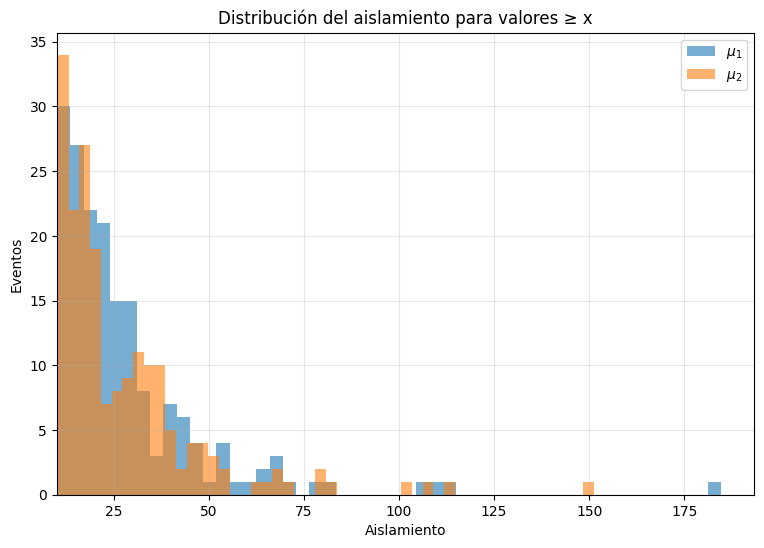

In [18]:
plt.figure(figsize=(9,6))
plt.hist(
    df_sel.loc[df_sel["iso1"] >= 10, "iso1"],
    bins=50,
    alpha=0.6,
    label=r"$\mu_1$"
)
plt.hist(
    df_sel.loc[df_sel["iso2"] >= 10, "iso2"],
    bins=50,
    alpha=0.6,
    label=r"$\mu_2$"
)
plt.xlabel("Aislamiento")
plt.ylabel("Eventos")
plt.title("Distribución del aislamiento para valores ≥ x")
plt.xlim(left=10)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La distribución muestra que la mayoría de los muones presentan valores bajos de aislamiento, mientras que existe una población menor con valores altos. Los valores altos indican una mayor actividad alrededor del muón. El aislamiento puede utilizarse como una variable adicional para distinguir candidatos limpios de Z-->mu+mu- de eventos con mayor actividad circundante. Sin embargo, el aislamiento por sí solo no permite determinar si un evento corresponde a un bosón Z; para ello resulta fundamental la reconstrucción de la masa invariante del par de muones.

In [11]:
df_sel[["pt1","eta1","phi1","Q1","iso1"]]

,pt1,eta1,phi1,Q1,iso1
0,54.7055,-0.4324,2.5742,1,0.4999
1,24.5872,-2.0522,2.8666,-1,0.0000
3,39.7394,-0.7123,-0.3123,1,0.0000
4,41.2998,-0.1571,-3.0408,1,1.2280
5,38.9425,0.3522,-2.2649,-1,0.0000
...,...,...,...,...,...
9994,38.1252,-0.4428,-2.2370,-1,0.0000
9996,39.4543,-1.1310,-2.0568,1,0.0000
9997,40.6034,-1.5051,-1.6758,-1,0.2012
9998,37.2853,1.0024,-2.1486,1,0.0000


In [12]:
df_sel[["iso1"]]

,iso1
0,0.4999
1,0.0000
3,0.0000
4,1.2280
5,0.0000
...,...
9994,0.0000
9996,0.0000
9997,0.2012
9998,0.0000


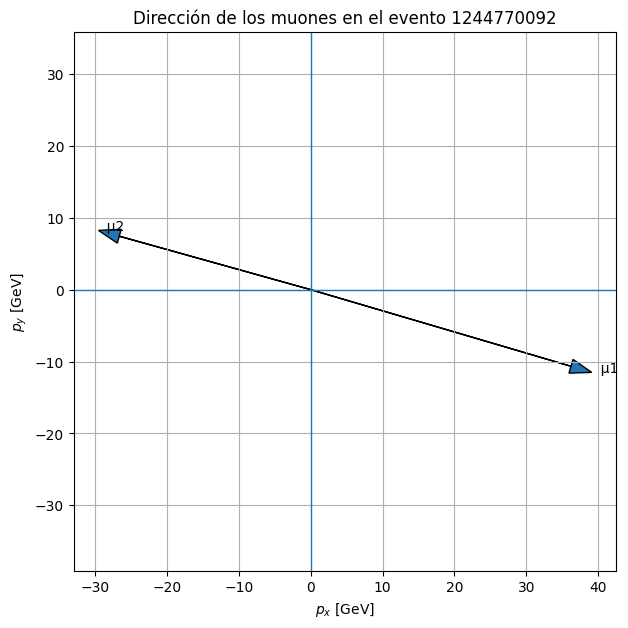

In [13]:
i = 9999
px1 = df.loc[i, "pt1"] * np.cos(df.loc[i, "phi1"])
py1 = df.loc[i, "pt1"] * np.sin(df.loc[i, "phi1"])
px2 = df.loc[i, "pt2"] * np.cos(df.loc[i, "phi2"])
py2 = df.loc[i, "pt2"] * np.sin(df.loc[i, "phi2"])
plt.figure(figsize=(7,7))

# Muón 1
plt.arrow(0, 0, px1, py1,
          length_includes_head=True,
          head_width=2)
# Muón 2
plt.arrow(0, 0, px2, py2,
          length_includes_head=True,
          head_width=2)

plt.text(px1, py1, "  μ1")
plt.text(px2, py2, "  μ2")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel(r"$p_x$ [GeV]")
plt.ylabel(r"$p_y$ [GeV]")
plt.title(f"Dirección de los muones en el evento {df.loc[i, 'Event']}")
plt.axis("equal")
plt.grid()
plt.show()

In [25]:
delta_phi = df["phi1"] - df["phi2"]
delta_phi = np.arctan2(
    np.sin(delta_phi),
    np.cos(delta_phi)
)

df["delta_phi_deg"] = np.degrees(np.abs(delta_phi))
df_z = df[
    (df["delta_phi_deg"] >= 175) &
    (df["M_mumu"] >= 90) &
    (df["M_mumu"] <= 92)
]
print("Eventos encontrados:", len(df_z))

Eventos encontrados: 858


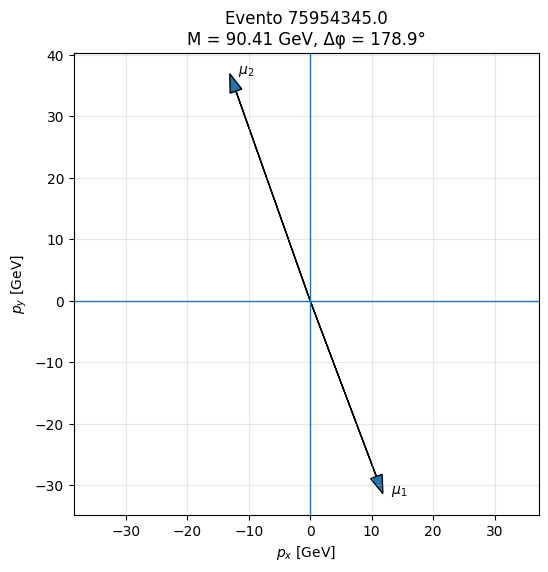

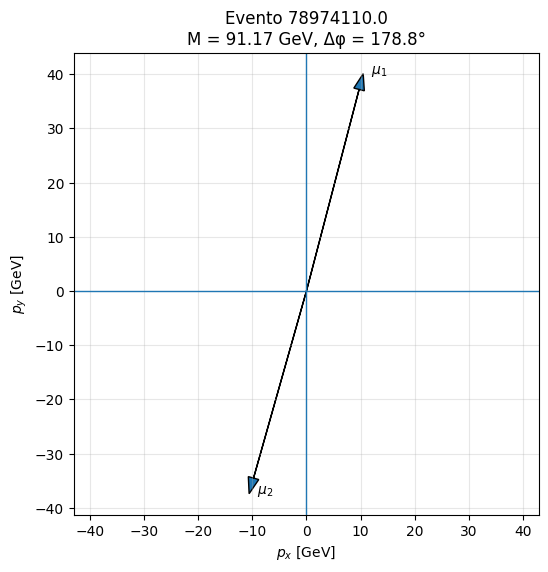

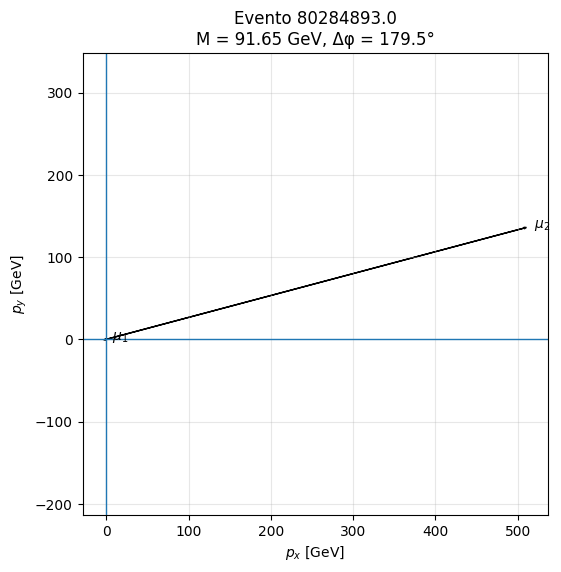

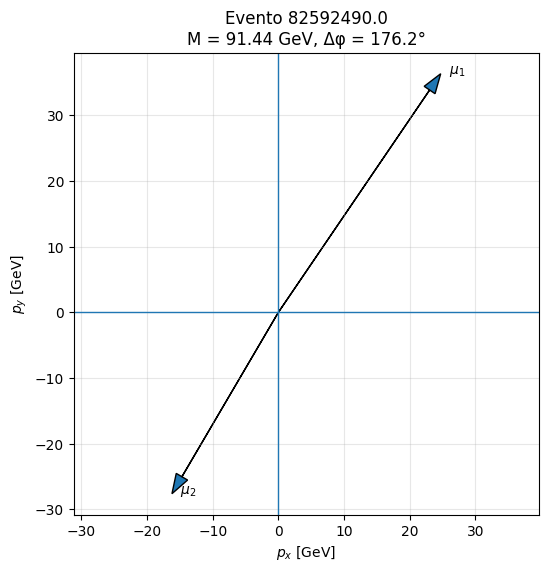

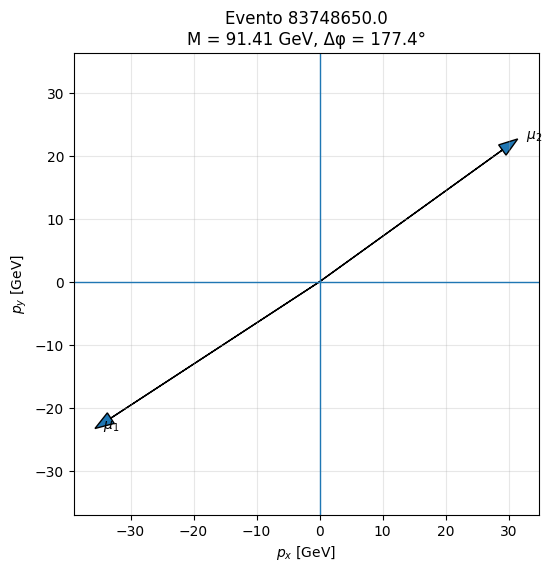

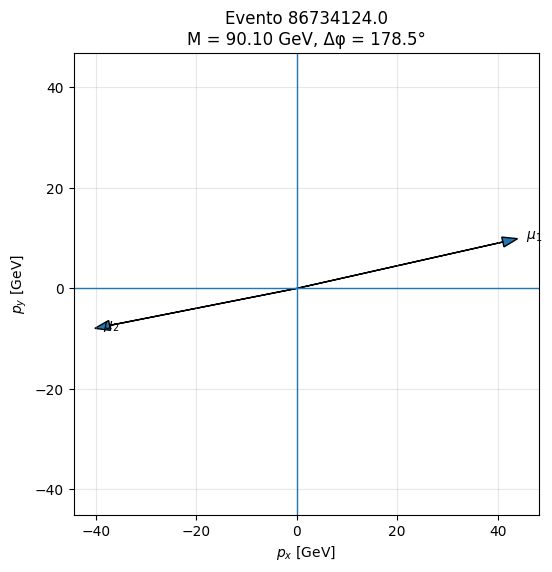

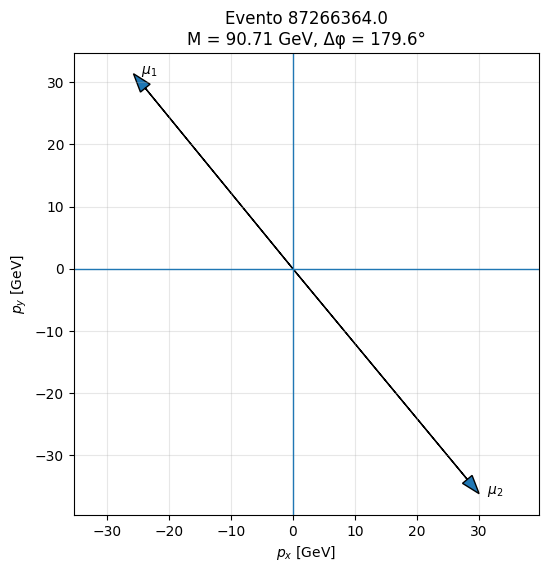

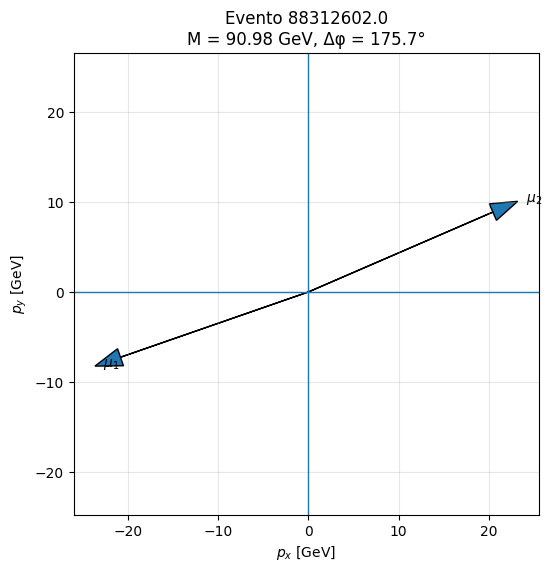

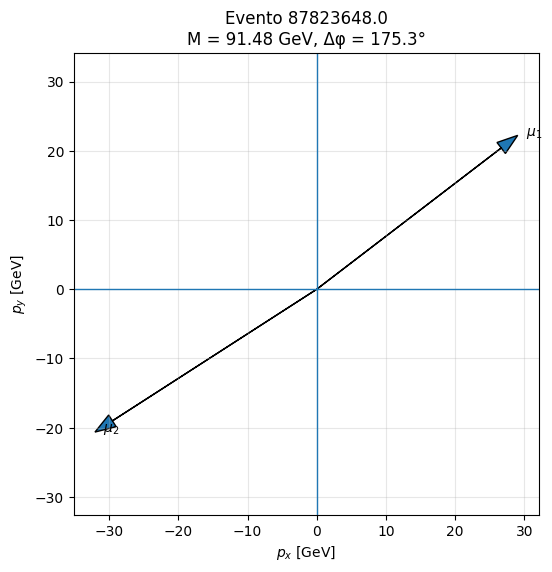

In [26]:
for i, evento in df_z.head(9).iterrows():
    px1 = evento["pt1"] * np.cos(evento["phi1"])
    py1 = evento["pt1"] * np.sin(evento["phi1"])
    px2 = evento["pt2"] * np.cos(evento["phi2"])
    py2 = evento["pt2"] * np.sin(evento["phi2"])
    plt.figure(figsize=(6,6))
    # Muón 1
    plt.arrow(
        0, 0,
        px1, py1,
        length_includes_head=True,
        head_width=2
    )
    # Muón 2
    plt.arrow(
        0, 0,
        px2, py2,
        length_includes_head=True,
        head_width=2
    )

    plt.text(px1, py1, r"  $\mu_1$")
    plt.text(px2, py2, r"  $\mu_2$")
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.xlabel(r"$p_x$ [GeV]")
    plt.ylabel(r"$p_y$ [GeV]")
    plt.title(
        f"Evento {evento['Event']}\n"
        f"M = {evento['M_mumu']:.2f} GeV, "
        f"Δφ = {evento['delta_phi_deg']:.1f}°"
    )
    plt.axis("equal")
    plt.grid(alpha=0.3)
    plt.show()

In [27]:
df.loc[i, "Event"] #loc del evento

np.int64(87823648)

# Conclusiones
A partir del análisis de la muestra de eventos con dos muones se pudieron estudiar sus principales características cinemáticas y reconstruir la masa invariante del par. La distribución de
M
μ
μ
 presenta una estructura compatible con la producción del bosón
Z
, cuyo máximo se encuentra alrededor de
91

G
e
V
. El ancho observado alrededor de este máximo no implica que la masa del bosón tenga una gran variación, sino que resulta de la combinación de la resolución del detector, las incertidumbres experimentales y los efectos cinemáticos y de reconstrucción presentes en los eventos.

El estudio de las variables
p
T
,
η
 y
ϕ
 permitió observar las características cinemáticas de los muones seleccionados. En particular, las distribuciones de
p
T
 y
η
 están determinadas en parte por la región de aceptación utilizada, mientras que la distribución azimutal permite estudiar la orientación de los muones en el plano transversal. Las variables de carga permiten identificar que los eventos de interés corresponden a pares de muones con cargas opuestas, como se espera para la reconstrucción de un estado neutro como el
Z
. Por su parte, el parámetro de impacto y el aislamiento proporcionan información sobre el origen de los muones y ayudan a distinguir muones compatibles con la interacción primaria de aquellos asociados a procesos secundarios o a actividad adicional en el evento.